In [6]:
print("Q1: Display the number of rows and number of columns")
print("Regno: URK23CS1010")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the data
df = pd.read_csv("Stores1a.csv")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Q1: Display the number of rows and number of columns
Regno: URK23CS1010
Number of rows: 50
Number of columns: 15


In [7]:
print("\nQ2: Display the number of categorical and number of numerical columns")
print("Regno: URK23CS1010")

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Number of numerical columns:", len(num_cols))
print("Numerical columns:", num_cols)
print("\nNumber of categorical columns:", len(cat_cols))
print("Categorical columns:", cat_cols)


Q2: Display the number of categorical and number of numerical columns
Regno: URK23CS1010
Number of numerical columns: 9
Numerical columns: ['Unit_price', 'Quantity', 'Tax', 'Total', 'cogs', 'Rating', 'Age', 'Quarterly_Tax', 'Price']

Number of categorical columns: 6
Categorical columns: ['Branch', 'City', 'Customer', 'Gender', 'Product line', 'Payment']


In [8]:
print("\nQ3: For all numerical columns, display the min, max and mean")
print("Regno: URK23CS1010")

num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    print(f"\nColumn: {col}")
    print(f"Min: {df[col].min()}")
    print(f"Max: {df[col].max()}")
    print(f"Mean: {df[col].mean():.2f}")


Q3: For all numerical columns, display the min, max and mean
Regno: URK23CS1010

Column: Unit_price
Min: 14.48
Max: 99.42
Mean: 60.24

Column: Quantity
Min: 1
Max: 60
Mean: 9.48

Column: Tax
Min: 1.537
Max: 39.48
Mean: 16.51

Column: Total
Min: 32.277
Max: 829.08
Mean: 346.67

Column: cogs
Min: 30.74
Max: 789.6
Mean: 330.16

Column: Rating
Min: 4.1
Max: 9.9
Mean: 6.72

Column: Age
Min: 22
Max: 32
Mean: 26.28

Column: Quarterly_Tax
Min: 19
Max: 234
Mean: 124.94

Column: Price
Min: 1448
Max: 9942
Mean: 6024.16



Q4: Calculate the 5 number summary for 'Age' column and correlate with box plot
Regno: URK23CS1010
5 Number Summary for Age:
Minimum: 22
Q1: 23.0
Median: 27.0
Q3: 29.0
Maximum: 32


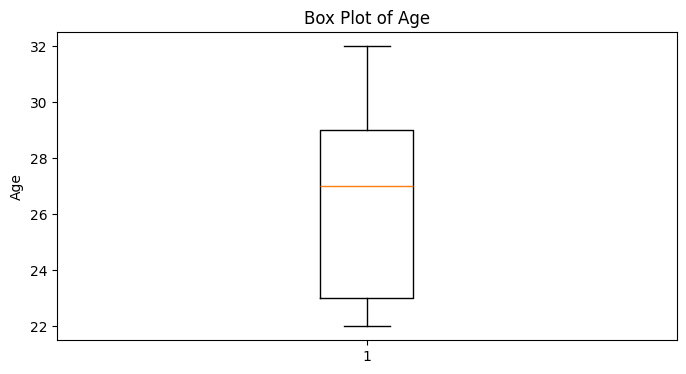

In [9]:
print("\nQ4: Calculate the 5 number summary for 'Age' column and correlate with box plot")
print("Regno: URK23CS1010")

# 5 number summary
min_val = df['Age'].min()
q1 = df['Age'].quantile(0.25)
median = df['Age'].median()
q3 = df['Age'].quantile(0.75)
max_val = df['Age'].max()

print("5 Number Summary for Age:")
print(f"Minimum: {min_val}")
print(f"Q1: {q1}")
print(f"Median: {median}")
print(f"Q3: {q3}")
print(f"Maximum: {max_val}")

# Box plot
plt.figure(figsize=(8, 4))
plt.boxplot(df['Age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')
plt.show()


Q5: Display the row index along with outlier values for the column 'Quantity' using IQR
Regno: URK23CS1010
Row indices and outlier values for Quantity:
Row 4: 60
Row 21: 55
Row 37: 57
Row 47: 56


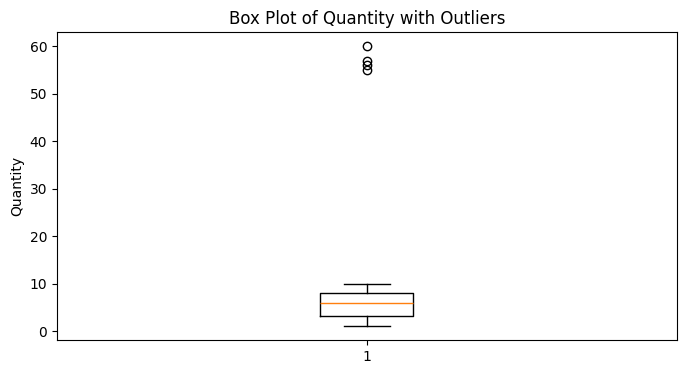

In [10]:
print("\nQ5: Display the row index along with outlier values for the column 'Quantity' using IQR")
print("Regno: URK23CS1010")

# Calculate IQR
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = df[(df['Quantity'] < lower_bound) | (df['Quantity'] > upper_bound)]
print("Row indices and outlier values for Quantity:")
for idx in outliers.index:
    print(f"Row {idx}: {df.loc[idx, 'Quantity']}")

# Box plot to verify
plt.figure(figsize=(8, 4))
plt.boxplot(df['Quantity'])
plt.title('Box Plot of Quantity with Outliers')
plt.ylabel('Quantity')
plt.show()


Q6: Display the row index along with outlier values and Z-score for the column 'Quantity'
Regno: URK23CS1010
Row indices, outlier values, and Z-scores for Quantity:
Row 4: Value=60, Z-score=3.55
Row 21: Value=55, Z-score=3.19
Row 37: Value=57, Z-score=3.33
Row 47: Value=56, Z-score=3.26


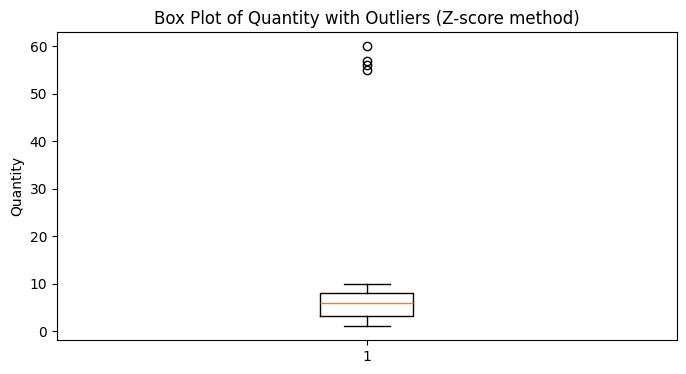

In [11]:
print("\nQ6: Display the row index along with outlier values and Z-score for the column 'Quantity'")
print("Regno: URK23CS1010")

from scipy import stats

# Calculate Z-scores
z_scores = np.abs(stats.zscore(df['Quantity'].dropna()))
threshold = 3

# Find outliers using Z-score
outlier_indices = np.where(z_scores > threshold)[0]
print("Row indices, outlier values, and Z-scores for Quantity:")
for idx in outlier_indices:
    actual_idx = df.index[idx]
    print(f"Row {actual_idx}: Value={df.loc[actual_idx, 'Quantity']}, Z-score={z_scores[idx]:.2f}")

# Box plot to verify
plt.figure(figsize=(8, 4))
plt.boxplot(df['Quantity'])
plt.title('Box Plot of Quantity with Outliers (Z-score method)')
plt.ylabel('Quantity')
plt.show()


Q7: Find the correlation for the input features 'Age', 'Price', 'Tax', 'Quarterly_Tax', 'Rating'
Regno: URK23CS1010
Correlation Matrix:
                    Age     Price       Tax  Quarterly_Tax    Rating
Age            1.000000  0.258092  0.319308      -0.178355 -0.219052
Price          0.258092  1.000000  0.614725      -0.105419 -0.167489
Tax            0.319308  0.614725  1.000000       0.170913 -0.126537
Quarterly_Tax -0.178355 -0.105419  0.170913       1.000000  0.306072
Rating        -0.219052 -0.167489 -0.126537       0.306072  1.000000


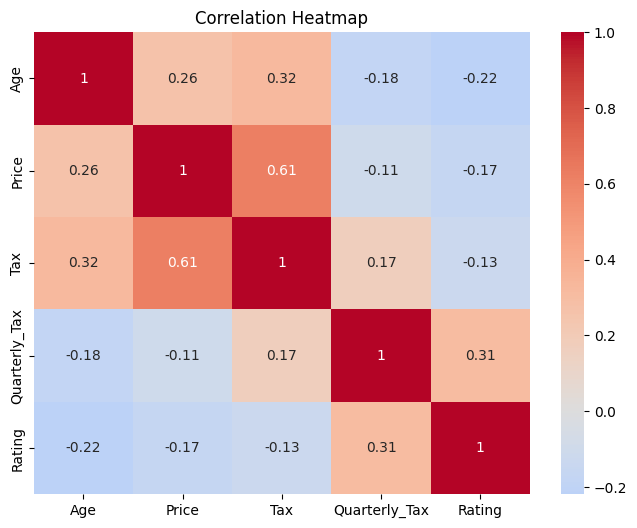

In [12]:
print("\nQ7: Find the correlation for the input features 'Age', 'Price', 'Tax', 'Quarterly_Tax', 'Rating'")
print("Regno: URK23CS1010")

features = ['Age', 'Price', 'Tax', 'Quarterly_Tax', 'Rating']
correlation_matrix = df[features].corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [13]:
print("\nQ8: Display feature pairs with high positive and high negative correlation values")
print("Regno: URK23CS1010")

features = ['Age', 'Price', 'Tax', 'Quarterly_Tax', 'Rating']
corr_matrix = df[features].corr()

# Create a copy and mask diagonal
corr_pairs = corr_matrix.copy()
np.fill_diagonal(corr_pairs.values, np.nan)

# Find max positive correlation (excluding diagonal)
max_pos = corr_pairs.max().max()
max_pos_pair = corr_pairs[corr_pairs == max_pos].stack().index[0]

# Find max negative correlation (excluding diagonal)
max_neg = corr_pairs.min().min()
max_neg_pair = corr_pairs[corr_pairs == max_neg].stack().index[0]

print(f"Highest positive correlation: {max_pos_pair[0]} - {max_pos_pair[1]} = {max_pos:.2f}")
print(f"Highest negative correlation: {max_neg_pair[0]} - {max_neg_pair[1]} = {max_neg:.2f}")


Q8: Display feature pairs with high positive and high negative correlation values
Regno: URK23CS1010
Highest positive correlation: Price - Tax = 0.61
Highest negative correlation: Age - Rating = -0.22


In [14]:
print("\nQ9: Display feature pairs with correlation value greater than 60%")
print("Regno: URK23CS1010")

features = ['Age', 'Price', 'Tax', 'Quarterly_Tax', 'Rating']
corr_matrix = df[features].corr()

print("Feature pairs with correlation > 0.6 or < -0.6:")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.6:
            print(f"{corr_matrix.columns[i]} - {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.2f}")


Q9: Display feature pairs with correlation value greater than 60%
Regno: URK23CS1010
Feature pairs with correlation > 0.6 or < -0.6:
Price - Tax: 0.61



Q10: Analyze the skewness of the 'Tax' column
Regno: URK23CS1010
Skewness value: 0.35
The feature is: No Skew (Approximately Symmetric)


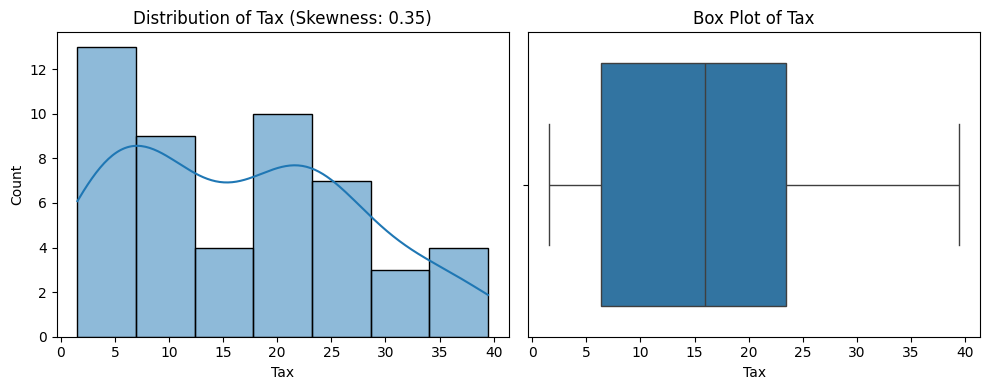

In [15]:
print("\nQ10: Analyze the skewness of the 'Tax' column")
print("Regno: URK23CS1010")

# Calculate skewness
skewness = df['Tax'].skew()
print(f"Skewness value: {skewness:.2f}")

if skewness > 0.5:
    skew_type = "Right Skew (Positively Skewed)"
elif skewness < -0.5:
    skew_type = "Left Skew (Negatively Skewed)"
else:
    skew_type = "No Skew (Approximately Symmetric)"

print(f"The feature is: {skew_type}")

# Distribution plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Tax'], kde=True)
plt.title(f'Distribution of Tax (Skewness: {skewness:.2f})')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Tax'])
plt.title('Box Plot of Tax')

plt.tight_layout()
plt.show()


Q11: Perform univariate analysis for categorical variable 'City' using bar plot
Regno: URK23CS1010
City counts:
City
Yangon       20
Mandalay     20
Naypyitaw    10
Name: count, dtype: int64


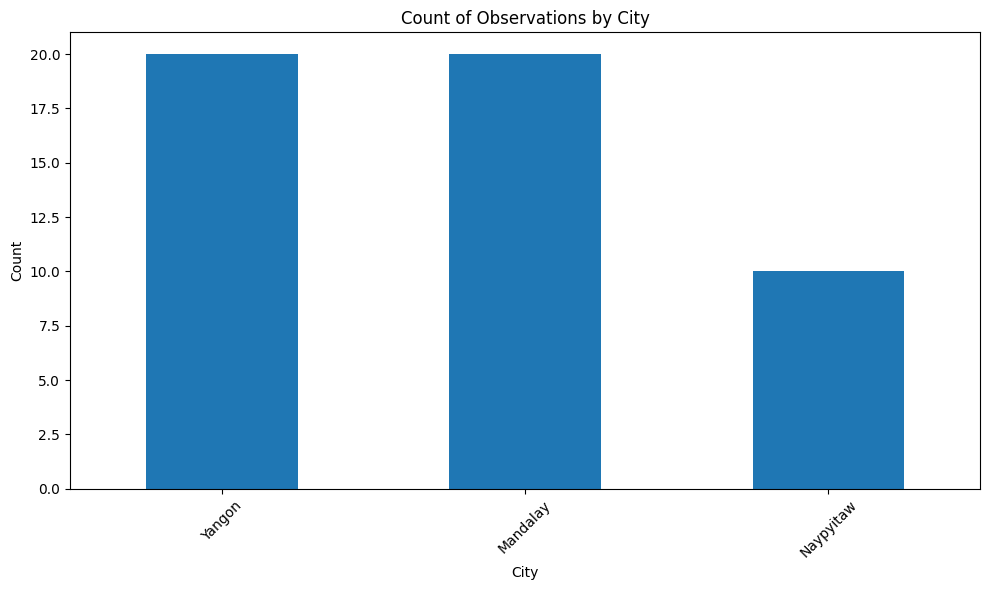

In [16]:
print("\nQ11: Perform univariate analysis for categorical variable 'City' using bar plot")
print("Regno: URK23CS1010")

city_counts = df['City'].value_counts()
print("City counts:")
print(city_counts)

# Bar plot
plt.figure(figsize=(10, 6))
city_counts.plot(kind='bar')
plt.title('Count of Observations by City')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Q12: Perform univariate analysis for continuous variable 'Rating' using swarm plot and violin plot
Regno: URK23CS1010
Rating Statistics:
Mean: 6.72
Median: 6.95
Std: 1.67


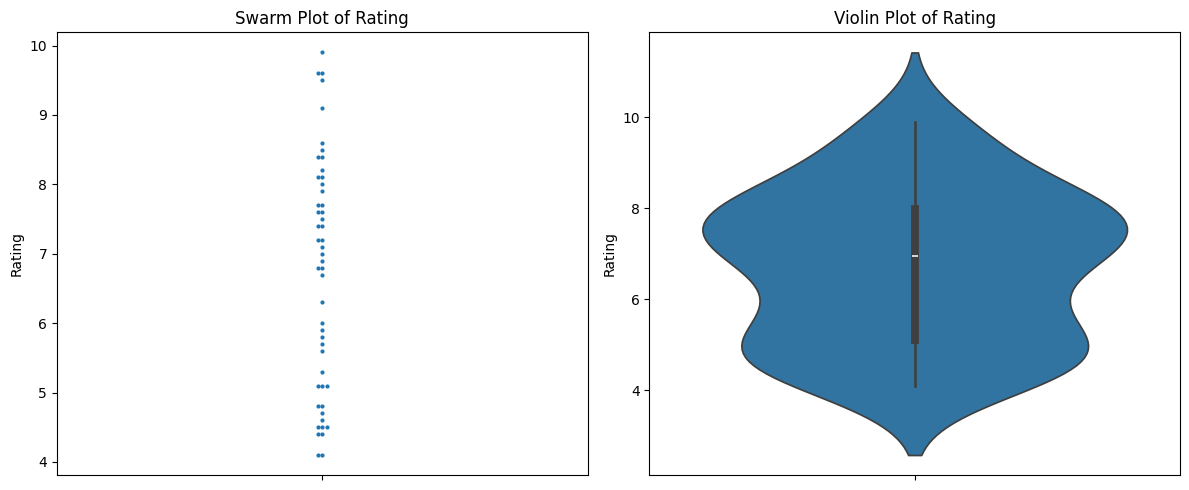

In [17]:
print("\nQ12: Perform univariate analysis for continuous variable 'Rating' using swarm plot and violin plot")
print("Regno: URK23CS1010")

print(f"Rating Statistics:")
print(f"Mean: {df['Rating'].mean():.2f}")
print(f"Median: {df['Rating'].median():.2f}")
print(f"Std: {df['Rating'].std():.2f}")

# Create plots
plt.figure(figsize=(12, 5))

# Swarm plot
plt.subplot(1, 2, 1)
sns.swarmplot(y=df['Rating'], size=3)
plt.title('Swarm Plot of Rating')
plt.ylabel('Rating')

# Violin plot
plt.subplot(1, 2, 2)
sns.violinplot(y=df['Rating'])
plt.title('Violin Plot of Rating')
plt.ylabel('Rating')

plt.tight_layout()
plt.show()


Q13: Display scatter plot showing relationship between Tax and cogs
Regno: URK23CS1010
Correlation between Tax and cogs: 1.00


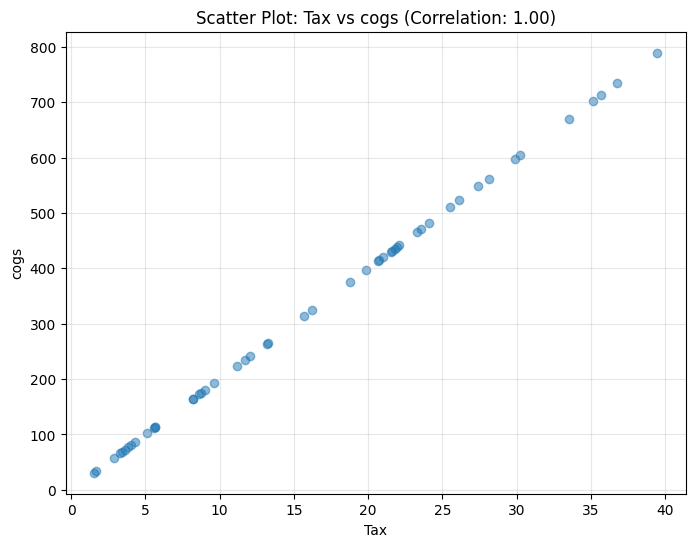

In [18]:
print("\nQ13: Display scatter plot showing relationship between Tax and cogs")
print("Regno: URK23CS1010")

# Calculate correlation
correlation = df['Tax'].corr(df['cogs'])
print(f"Correlation between Tax and cogs: {correlation:.2f}")

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df['Tax'], df['cogs'], alpha=0.5)
plt.title(f'Scatter Plot: Tax vs cogs (Correlation: {correlation:.2f})')
plt.xlabel('Tax')
plt.ylabel('cogs')
plt.grid(True, alpha=0.3)
plt.show()


Q14: Perform bivariate analysis between Gender and Age using categorical box plot
Regno: URK23CS1010
Age statistics by Gender:
        count       mean       std   min   25%   50%    75%   max
Gender                                                           
Female   24.0  26.000000  3.310064  22.0  23.0  25.5  28.25  32.0
Male     26.0  26.538462  3.062427  22.0  24.0  27.0  29.00  32.0


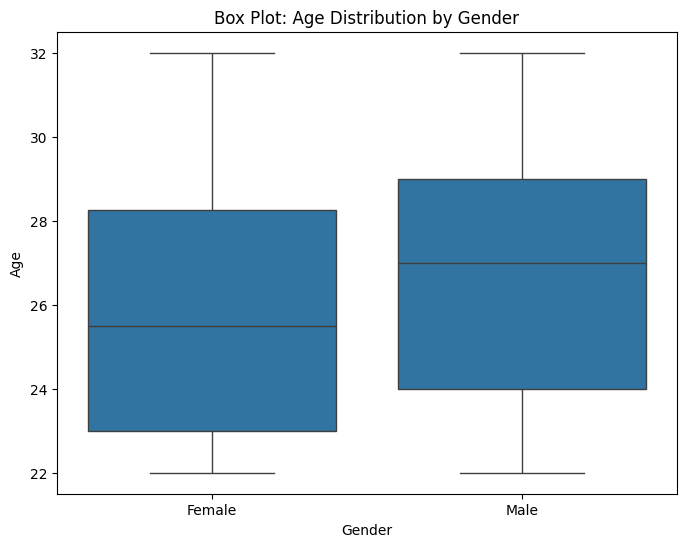

In [19]:
print("\nQ14: Perform bivariate analysis between Gender and Age using categorical box plot")
print("Regno: URK23CS1010")

# Statistics by gender
gender_stats = df.groupby('Gender')['Age'].describe()
print("Age statistics by Gender:")
print(gender_stats)

# Box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='Age', data=df)
plt.title('Box Plot: Age Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.show()


Q15: Perform bivariate analysis between Gender and Customer using crosstab and count plot
Regno: URK23CS1010
Crosstab of Gender vs Customer:
Customer  Member  Normal
Gender                  
Female        15       9
Male          12      14


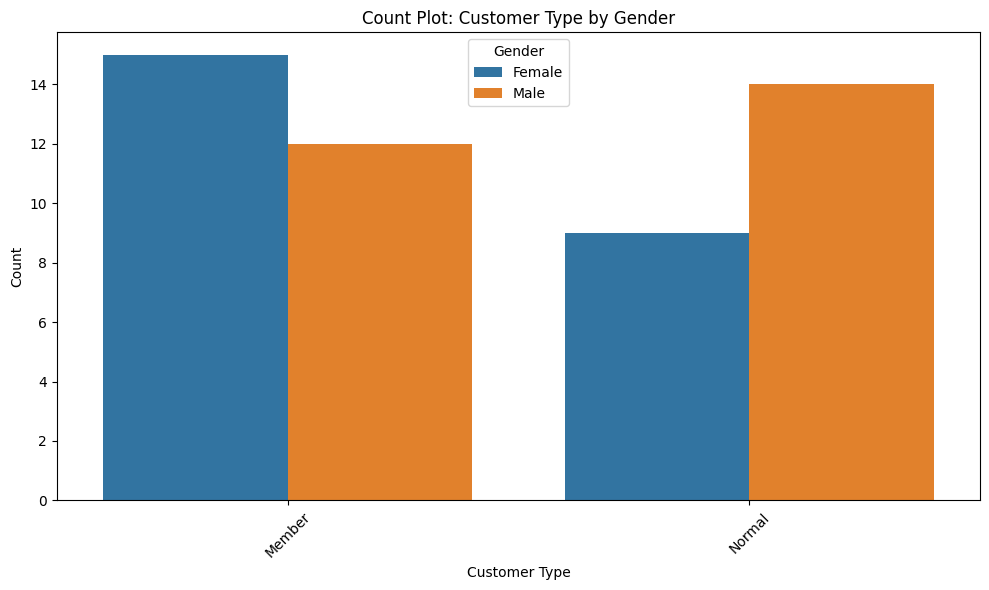

In [20]:
print("\nQ15: Perform bivariate analysis between Gender and Customer using crosstab and count plot")
print("Regno: URK23CS1010")

# Create crosstab
crosstab = pd.crosstab(df['Gender'], df['Customer'])
print("Crosstab of Gender vs Customer:")
print(crosstab)

# Count plot
plt.figure(figsize=(10, 6))
sns.countplot(x='Customer', hue='Gender', data=df)
plt.title('Count Plot: Customer Type by Gender')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


Q16: Perform multivariate analysis using pair plot with City as hue
Regno: URK23CS1010


<Figure size 1200x1000 with 0 Axes>

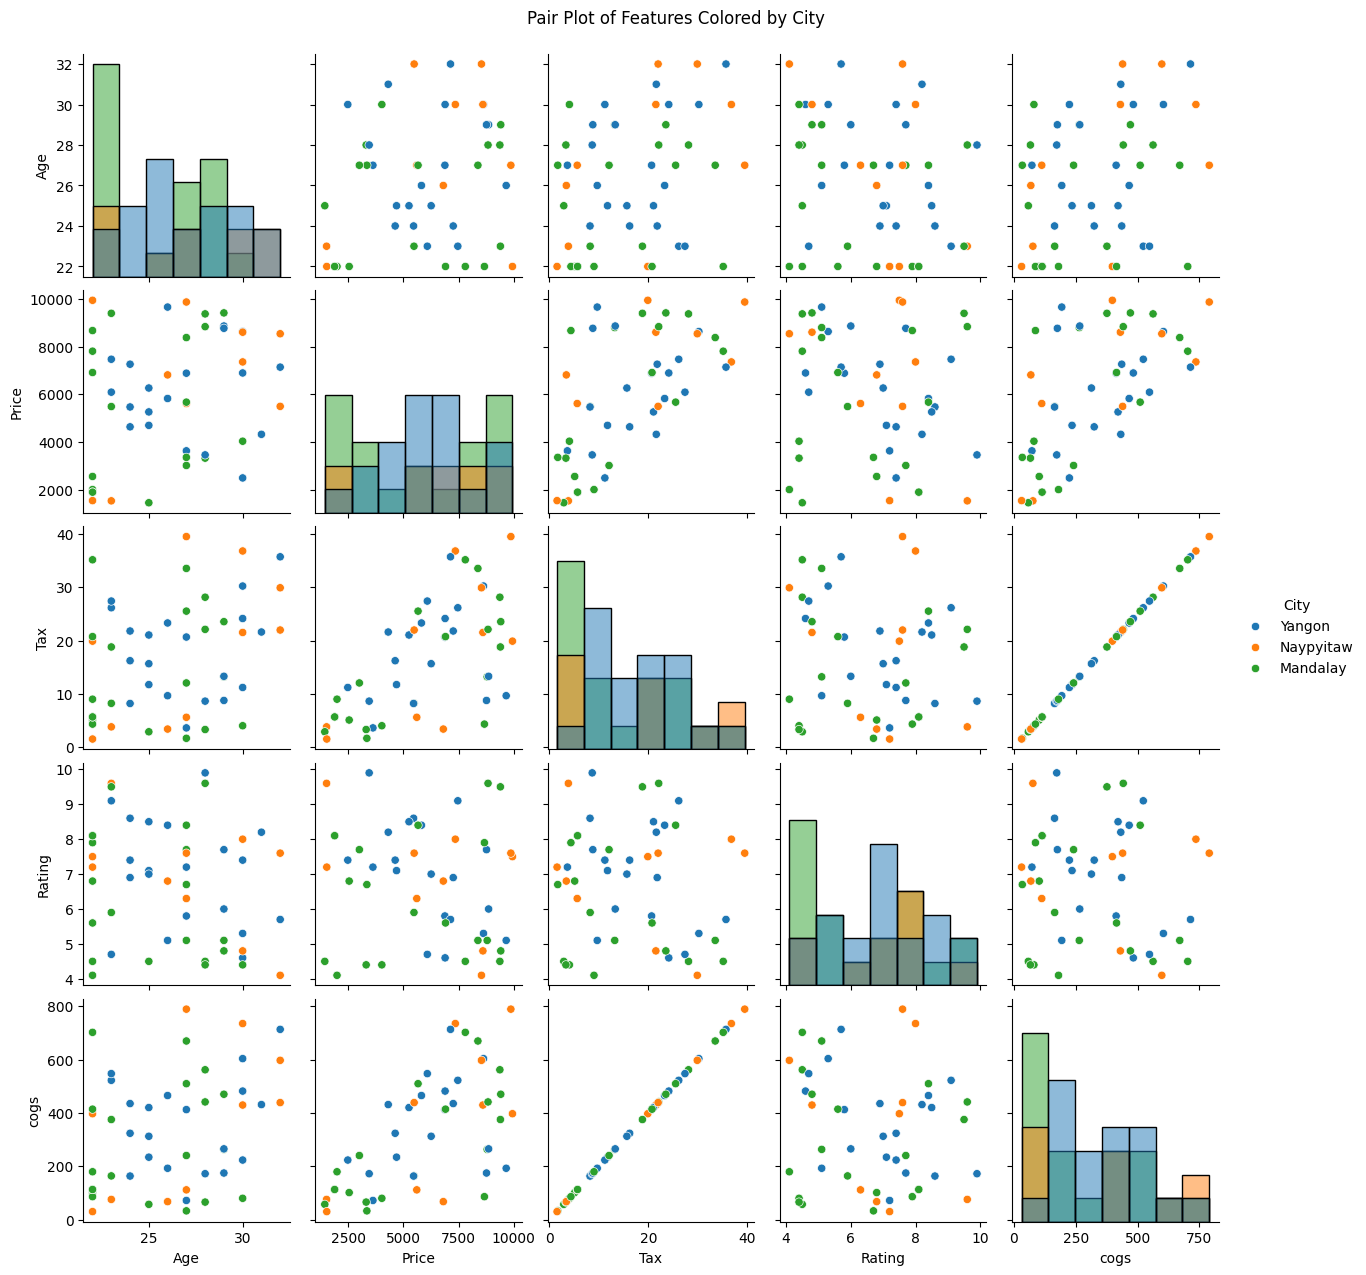

In [21]:
print("\nQ16: Perform multivariate analysis using pair plot with City as hue")
print("Regno: URK23CS1010")

features = ['Age', 'Price', 'Tax', 'Rating', 'cogs', 'City']

# Create pair plot
plt.figure(figsize=(12, 10))
sns.pairplot(data=df[features], hue='City', diag_kind='hist')
plt.suptitle('Pair Plot of Features Colored by City', y=1.02)
plt.show()

In [22]:
print("\nPART B - Data Pre-processing")
print("\nQ17: Identify columns with null value and calculate % of missing values")
print("Regno: URK23CS1010")

# Read the data
df_b = pd.read_csv("Stores1b.csv")
print("Original DataFrame shape:", df_b.shape)

# Find null values
null_cols = df_b.columns[df_b.isnull().any()].tolist()
print("\nColumns with null values:", null_cols)

# Calculate percentage of missing values
for col in null_cols:
    null_count = df_b[col].isnull().sum()
    null_percent = (null_count / len(df_b)) * 100
    print(f"{col}: {null_count} missing values ({null_percent:.2f}%)")


PART B - Data Pre-processing

Q17: Identify columns with null value and calculate % of missing values
Regno: URK23CS1010
Original DataFrame shape: (51, 15)

Columns with null values: ['Branch', 'Product line', 'Quarterly_Tax']
Branch: 4 missing values (7.84%)
Product line: 18 missing values (35.29%)
Quarterly_Tax: 4 missing values (7.84%)


In [23]:
print("\nQ18: Replace missing value with mean for numerical column (<10% missing)")
print("Regno: URK23CS1010")

# Find numerical columns with missing values <10%
num_cols = df_b.select_dtypes(include=[np.number]).columns
print("Before imputation:")
print(df_b[num_cols].isnull().sum())

# Create a copy
df_b_mean = df_b.copy()

# Impute with mean
for col in num_cols:
    if df_b[col].isnull().sum() > 0:
        missing_percent = (df_b[col].isnull().sum() / len(df_b)) * 100
        if missing_percent < 10:
            mean_val = df_b[col].mean()
            df_b_mean[col].fillna(mean_val, inplace=True)
            print(f"\nImputed {col} with mean: {mean_val:.2f}")

print("\nAfter mean imputation:")
print(df_b_mean[num_cols].isnull().sum())


Q18: Replace missing value with mean for numerical column (<10% missing)
Regno: URK23CS1010
Before imputation:
Unit_price       0
Quantity         0
Tax              0
Total            0
cogs             0
Rating           0
Age              0
Quarterly_Tax    4
Price            0
dtype: int64

Imputed Quarterly_Tax with mean: 124.00

After mean imputation:
Unit_price       0
Quantity         0
Tax              0
Total            0
cogs             0
Rating           0
Age              0
Quarterly_Tax    0
Price            0
dtype: int64


C:\Users\aaduv\AppData\Local\Temp\ipykernel_24596\2649131876.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_b_mean[col].fillna(mean_val, inplace=True)


In [24]:
print("\nQ19: Perform imputation using nearest method for numerical column (<10% missing)")
print("Regno: URK23CS1010")

# Find numerical columns with missing values <10%
num_cols = df_b.select_dtypes(include=[np.number]).columns
print("Before imputation:")
print(df_b[num_cols].isnull().sum())

# Create a copy
df_b_nearest = df_b.copy()

# Impute with nearest value (forward fill then backward fill)
for col in num_cols:
    if df_b[col].isnull().sum() > 0:
        missing_percent = (df_b[col].isnull().sum() / len(df_b)) * 100
        if missing_percent < 10:
            df_b_nearest[col] = df_b_nearest[col].fillna(method='ffill').fillna(method='bfill')
            print(f"\nImputed {col} using nearest method")

print("\nAfter nearest imputation:")
print(df_b_nearest[num_cols].isnull().sum())


Q19: Perform imputation using nearest method for numerical column (<10% missing)
Regno: URK23CS1010
Before imputation:
Unit_price       0
Quantity         0
Tax              0
Total            0
cogs             0
Rating           0
Age              0
Quarterly_Tax    4
Price            0
dtype: int64

Imputed Quarterly_Tax using nearest method

After nearest imputation:
Unit_price       0
Quantity         0
Tax              0
Total            0
cogs             0
Rating           0
Age              0
Quarterly_Tax    0
Price            0
dtype: int64


C:\Users\aaduv\AppData\Local\Temp\ipykernel_24596\426709275.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_b_nearest[col] = df_b_nearest[col].fillna(method='ffill').fillna(method='bfill')


In [25]:
print("\nQ20: Perform mode imputation for categorical data (<10% missing)")
print("Regno: URK23CS1010")

# Find categorical columns with missing values
cat_cols = df_b.select_dtypes(include=['object']).columns
print("Before imputation:")
print(df_b[cat_cols].isnull().sum())

# Create a copy
df_b_mode = df_b.copy()

# Impute with mode
for col in cat_cols:
    if df_b[col].isnull().sum() > 0:
        missing_percent = (df_b[col].isnull().sum() / len(df_b)) * 100
        if missing_percent < 10:
            mode_val = df_b[col].mode()[0]
            df_b_mode[col].fillna(mode_val, inplace=True)
            print(f"\nImputed {col} with mode: {mode_val}")

print("\nAfter mode imputation:")
print(df_b_mode[cat_cols].isnull().sum())


Q20: Perform mode imputation for categorical data (<10% missing)
Regno: URK23CS1010
Before imputation:
Branch           4
City             0
Customer         0
Gender           0
Product line    18
Payment          0
dtype: int64

Imputed Branch with mode: A

After mode imputation:
Branch           0
City             0
Customer         0
Gender           0
Product line    18
Payment          0
dtype: int64


C:\Users\aaduv\AppData\Local\Temp\ipykernel_24596\3318554472.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_b_mode[col].fillna(mode_val, inplace=True)


In [26]:
print("\nQ21: Drop columns with more than 10% missing values")
print("Regno: URK23CS1010")

print("Before dropping:")
print(f"Shape: {df_b.shape}")
print(f"Columns: {df_b.columns.tolist()}")

# Identify columns to drop
cols_to_drop = []
for col in df_b.columns:
    missing_percent = (df_b[col].isnull().sum() / len(df_b)) * 100
    if missing_percent > 10:
        cols_to_drop.append(col)
        print(f"{col}: {missing_percent:.2f}% missing - will be dropped")

# Drop columns
df_b_dropped = df_b.drop(columns=cols_to_drop)

print("\nAfter dropping:")
print(f"Shape: {df_b_dropped.shape}")
print(f"Columns: {df_b_dropped.columns.tolist()}")


Q21: Drop columns with more than 10% missing values
Regno: URK23CS1010
Before dropping:
Shape: (51, 15)
Columns: ['Branch', 'City', 'Customer', 'Gender', 'Product line', 'Unit_price', 'Quantity', 'Tax', 'Total', 'Payment', 'cogs', 'Rating', 'Age', 'Quarterly_Tax', 'Price']
Product line: 35.29% missing - will be dropped

After dropping:
Shape: (51, 14)
Columns: ['Branch', 'City', 'Customer', 'Gender', 'Unit_price', 'Quantity', 'Tax', 'Total', 'Payment', 'cogs', 'Rating', 'Age', 'Quarterly_Tax', 'Price']


In [27]:
print("\nQ22: Drop rows with outlier Z-score >3 for Quantity")
print("Regno: URK23CS1010")

from scipy import stats

print("Before dropping:")
print(f"Shape: {df_b.shape}")

# Calculate Z-scores
z_scores = np.abs(stats.zscore(df_b['Quantity'].dropna()))
outlier_indices = df_b.index[np.where(z_scores > 3)[0]]

print(f"Number of outlier rows: {len(outlier_indices)}")
print(f"Outlier indices: {outlier_indices.tolist()}")

# Drop outliers
df_b_no_outliers = df_b.drop(index=outlier_indices)

print("\nAfter dropping outliers:")
print(f"Shape: {df_b_no_outliers.shape}")


Q22: Drop rows with outlier Z-score >3 for Quantity
Regno: URK23CS1010
Before dropping:
Shape: (51, 15)
Number of outlier rows: 4
Outlier indices: [4, 21, 37, 47]

After dropping outliers:
Shape: (47, 15)


In [28]:
print("\nQ23: Find % of duplicate rows with all columns having same value")
print("Regno: URK23CS1010")

# Find duplicate rows
duplicates = df_b.duplicated()
duplicate_count = duplicates.sum()
duplicate_percent = (duplicate_count / len(df_b)) * 100

print(f"Number of duplicate rows: {duplicate_count}")
print(f"Percentage of duplicate rows: {duplicate_percent:.2f}%")


Q23: Find % of duplicate rows with all columns having same value
Regno: URK23CS1010
Number of duplicate rows: 2
Percentage of duplicate rows: 3.92%


In [29]:
print("\nQ24: Drop the duplicates and display size before & after dropping")
print("Regno: URK23CS1010")

print("Before dropping duplicates:")
print(f"Shape: {df_b.shape}")

# Drop duplicates
df_b_no_duplicates = df_b.drop_duplicates()

print("\nAfter dropping duplicates:")
print(f"Shape: {df_b_no_duplicates.shape}")
print(f"Rows removed: {df_b.shape[0] - df_b_no_duplicates.shape[0]}")


Q24: Drop the duplicates and display size before & after dropping
Regno: URK23CS1010
Before dropping duplicates:
Shape: (51, 15)

After dropping duplicates:
Shape: (49, 15)
Rows removed: 2


In [30]:
print("\nQ25: Find % of duplicate rows based on specific columns")
print("Regno: URK23CS1010")

specific_cols = ['Customer', 'Product line', 'Age', 'Gender']

# Find duplicates based on specific columns
duplicates_specific = df_b.duplicated(subset=specific_cols)
duplicate_count = duplicates_specific.sum()
duplicate_percent = (duplicate_count / len(df_b)) * 100

print(f"Columns considered: {specific_cols}")
print(f"Number of duplicate rows: {duplicate_count}")
print(f"Percentage of duplicate rows: {duplicate_percent:.2f}%")


Q25: Find % of duplicate rows based on specific columns
Regno: URK23CS1010
Columns considered: ['Customer', 'Product line', 'Age', 'Gender']
Number of duplicate rows: 8
Percentage of duplicate rows: 15.69%


In [31]:
print("\nQ26: Drop duplicates based on specific columns and display size")
print("Regno: URK23CS1010")

specific_cols = ['Customer', 'Product line', 'Age', 'Gender']

print("Before dropping duplicates:")
print(f"Shape: {df_b.shape}")

# Drop duplicates based on specific columns
df_b_specific_dedup = df_b.drop_duplicates(subset=specific_cols)

print("\nAfter dropping duplicates (based on specific columns):")
print(f"Shape: {df_b_specific_dedup.shape}")
print(f"Rows removed: {df_b.shape[0] - df_b_specific_dedup.shape[0]}")


Q26: Drop duplicates based on specific columns and display size
Regno: URK23CS1010
Before dropping duplicates:
Shape: (51, 15)

After dropping duplicates (based on specific columns):
Shape: (43, 15)
Rows removed: 8



Q27: Perform min-max normalization for 'Age' and analyze with scatter plot
Regno: URK23CS1010
Original Age:
Min: 22
Max: 32
Mean: 26.22

Normalized Age (Min-Max):
Min: 0.00
Max: 1.00
Mean: 0.42


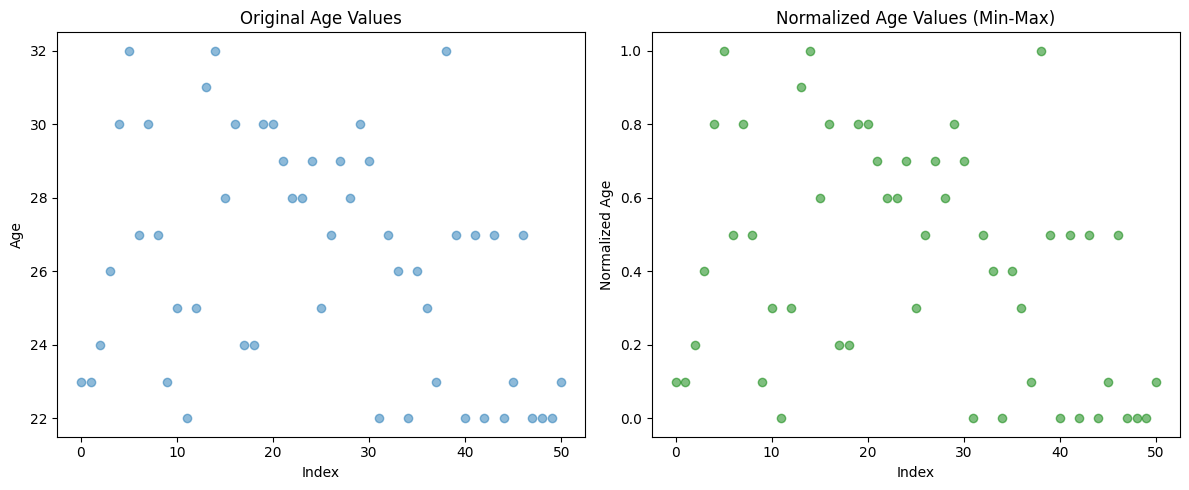

In [32]:
print("\nQ27: Perform min-max normalization for 'Age' and analyze with scatter plot")
print("Regno: URK23CS1010")

# Original Age statistics
print("Original Age:")
print(f"Min: {df_b['Age'].min()}")
print(f"Max: {df_b['Age'].max()}")
print(f"Mean: {df_b['Age'].mean():.2f}")

# Min-max normalization
df_b_minmax = df_b.copy()
df_b_minmax['Age_normalized'] = (df_b['Age'] - df_b['Age'].min()) / (df_b['Age'].max() - df_b['Age'].min())

print("\nNormalized Age (Min-Max):")
print(f"Min: {df_b_minmax['Age_normalized'].min():.2f}")
print(f"Max: {df_b_minmax['Age_normalized'].max():.2f}")
print(f"Mean: {df_b_minmax['Age_normalized'].mean():.2f}")

# Scatter plot comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(range(len(df_b)), df_b['Age'], alpha=0.5)
plt.title('Original Age Values')
plt.xlabel('Index')
plt.ylabel('Age')

plt.subplot(1, 2, 2)
plt.scatter(range(len(df_b_minmax)), df_b_minmax['Age_normalized'], alpha=0.5, color='green')
plt.title('Normalized Age Values (Min-Max)')
plt.xlabel('Index')
plt.ylabel('Normalized Age')

plt.tight_layout()
plt.show()


Q28: Perform Z-score normalization for 'Age' and analyze with scatter plot
Regno: URK23CS1010
Original Age:
Mean: 26.22
Std: 3.16

Normalized Age (Z-score):
Mean: 0.00
Std: 1.01
Min: -1.35
Max: 1.85


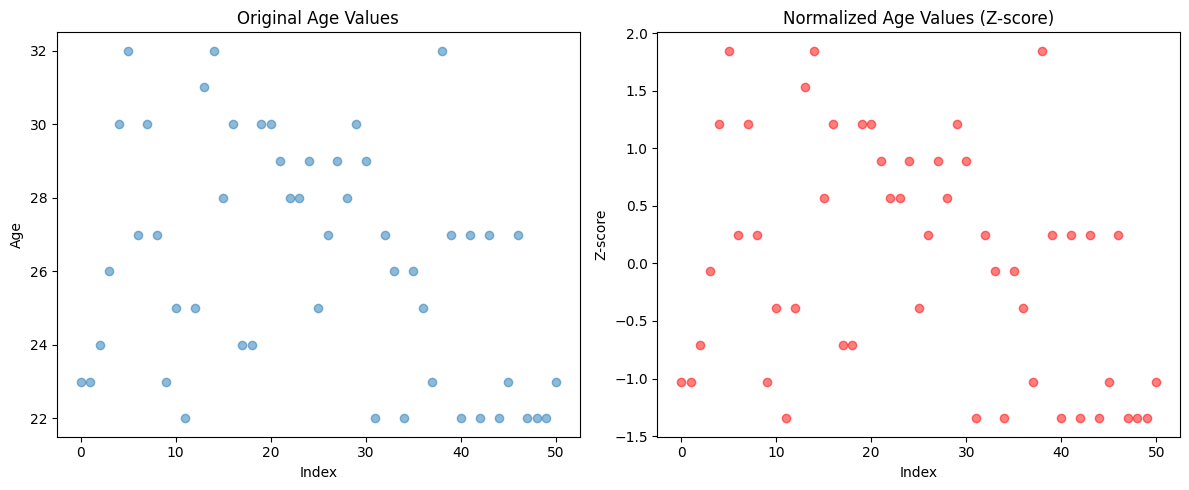

In [33]:
print("\nQ28: Perform Z-score normalization for 'Age' and analyze with scatter plot")
print("Regno: URK23CS1010")

from scipy import stats

# Original Age statistics
print("Original Age:")
print(f"Mean: {df_b['Age'].mean():.2f}")
print(f"Std: {df_b['Age'].std():.2f}")

# Z-score normalization
df_b_zscore = df_b.copy()
df_b_zscore['Age_zscore'] = stats.zscore(df_b['Age'])

print("\nNormalized Age (Z-score):")
print(f"Mean: {df_b_zscore['Age_zscore'].mean():.2f}")
print(f"Std: {df_b_zscore['Age_zscore'].std():.2f}")
print(f"Min: {df_b_zscore['Age_zscore'].min():.2f}")
print(f"Max: {df_b_zscore['Age_zscore'].max():.2f}")

# Scatter plot comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(range(len(df_b)), df_b['Age'], alpha=0.5)
plt.title('Original Age Values')
plt.xlabel('Index')
plt.ylabel('Age')

plt.subplot(1, 2, 2)
plt.scatter(range(len(df_b_zscore)), df_b_zscore['Age_zscore'], alpha=0.5, color='red')
plt.title('Normalized Age Values (Z-score)')
plt.xlabel('Index')
plt.ylabel('Z-score')

plt.tight_layout()
plt.show()

In [34]:
print("\nQ29: Perform label encoding for categorical feature 'Payment'")
print("Regno: URK23CS1010")

from sklearn.preprocessing import LabelEncoder

# Original values
print("Original Payment values:")
print(df_b['Payment'].value_counts())

# Label encoding
df_b_label = df_b.copy()
le = LabelEncoder()
df_b_label['Payment_encoded'] = le.fit_transform(df_b['Payment'])

print("\nAfter Label Encoding:")
print("Mapping:")
for i, category in enumerate(le.classes_):
    print(f"{category} -> {i}")

print("\nFirst 10 rows with encoded values:")
print(df_b_label[['Payment', 'Payment_encoded']].head(10))


Q29: Perform label encoding for categorical feature 'Payment'
Regno: URK23CS1010
Original Payment values:
Payment
Ewallet        22
Cash           15
Credit card    14
Name: count, dtype: int64

After Label Encoding:
Mapping:
Cash -> 0
Credit card -> 1
Ewallet -> 2

First 10 rows with encoded values:
       Payment  Payment_encoded
0      Ewallet                2
1         Cash                0
2  Credit card                1
3      Ewallet                2
4      Ewallet                2
5      Ewallet                2
6      Ewallet                2
7      Ewallet                2
8  Credit card                1
9  Credit card                1


In [35]:
print("\nQ30: Perform one-hot encoding for categorical feature 'Payment'")
print("Regno: URK23CS1010")

# Original values
print("Original Payment values:")
print(df_b['Payment'].value_counts())

# One-hot encoding
df_b_onehot = df_b.copy()
one_hot = pd.get_dummies(df_b['Payment'], prefix='Payment')

# Concatenate with original dataframe
df_b_onehot = pd.concat([df_b_onehot, one_hot], axis=1)

print("\nOne-hot encoded columns:")
print(one_hot.columns.tolist())
print(f"\nShape before one-hot encoding: {df_b.shape}")
print(f"Shape after one-hot encoding: {df_b_onehot.shape}")

print("\nFirst 10 rows with one-hot encoded values:")
print(df_b_onehot[['Payment'] + one_hot.columns.tolist()].head(10))


Q30: Perform one-hot encoding for categorical feature 'Payment'
Regno: URK23CS1010
Original Payment values:
Payment
Ewallet        22
Cash           15
Credit card    14
Name: count, dtype: int64

One-hot encoded columns:
['Payment_Cash', 'Payment_Credit card', 'Payment_Ewallet']

Shape before one-hot encoding: (51, 15)
Shape after one-hot encoding: (51, 18)

First 10 rows with one-hot encoded values:
       Payment  Payment_Cash  Payment_Credit card  Payment_Ewallet
0      Ewallet         False                False             True
1         Cash          True                False            False
2  Credit card         False                 True            False
3      Ewallet         False                False             True
4      Ewallet         False                False             True
5      Ewallet         False                False             True
6      Ewallet         False                False             True
7      Ewallet         False                False         